# Video Game Sales Prediction

## Problem Definition

For this project I'm looking at video game sales data and trying to predict how well a game will sell globally. The features I'll be using are things like what platform it came out on, the genre, the year it released, and who published it. Since I'm predicting a number (global sales in millions), this is a regression problem.

Dataset: Video Game Sales from Kaggle  
https://www.kaggle.com/datasets/gregorut/videogamesales

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset

Loading the CSV file and taking a first look at the data.

In [58]:
frame = pd.read_csv("vgsales.csv")
frame.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,Asteroids,2600,1980,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
1,545,Missile Command,2600,1980,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
2,1768,Kaboom!,2600,1980,Misc,Activision,1.07,0.07,0.0,0.01,1.15
3,1971,Defender,2600,1980,Misc,Atari,0.99,0.05,0.0,0.01,1.05
4,2671,Boxing,2600,1980,Fighting,Activision,0.72,0.04,0.0,0.01,0.77


In [59]:
print(frame.shape)
print(frame.dtypes)

(16324, 11)
Rank              int64
Name                str
Platform            str
Year              int64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [60]:
print(frame.isnull().sum())

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64


## Data Preparation and Preprocessing

Now I need to clean the data and get it ready for modeling. There are 36 null values in the Publisher column, so I'll drop those rows since it's a small amount. I also need to drop columns that won't help with prediction and encode the categorical columns since the model needs numbers.

In [61]:
prep_frame = frame.dropna().copy()
prep_frame = prep_frame.drop(columns=["Name", "Rank"])
prep_frame.shape

(16288, 9)

In [62]:
encoded_frame = pd.get_dummies(prep_frame, columns=["Platform", "Genre", "Publisher"])
encoded_frame.shape

(16288, 625)

In [63]:
target = encoded_frame["Global_Sales"]
features = encoded_frame.drop(columns=["Global_Sales", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"])

train_features, test_features, train_target, test_target = train_test_split(features, target, test_size=0.2, random_state=42)

print(train_features.shape)
print(test_features.shape)

(13030, 620)
(3258, 620)


## Model Training

I'm using a Decision Tree Regressor for this. It's a good fit for this dataset because it can handle a mix of different types of features and doesn't need scaling.

In [64]:
sales_model = DecisionTreeRegressor(random_state=42, max_depth=6)
sales_model.fit(train_features, train_target)
print("model trained")

model trained


## Model Evaluation

Now I'll check how well the model performed using RMSE and R2. RMSE tells me how far off the predictions are on average and R2 shows how much of the variation in sales the model is actually capturing.

In [65]:
predictions = sales_model.predict(test_features)

rmse_score = np.sqrt(mean_squared_error(test_target, predictions))
r2 = r2_score(test_target, predictions)

print("RMSE:", round(rmse_score, 4))
print("R2:", round(r2, 4))

RMSE: 1.894
R2: 0.0923


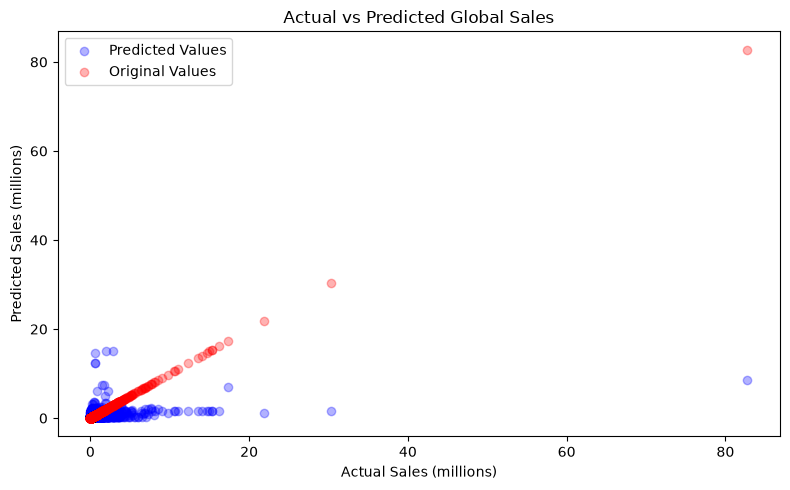

In [67]:
plt.figure(figsize=(8, 5))
plt.scatter(test_target, predictions, alpha=0.3, color='blue', label='Predicted Values')
plt.scatter(test_target, test_target, alpha=0.3, color='red', label='Original Values')
plt.xlabel("Actual Sales (millions)")
plt.ylabel("Predicted Sales (millions)")
plt.title("Actual vs Predicted Global Sales")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Summary

For this project I tried to predict global video game sales using a Decision Tree Regressor. The dataset came from Kaggle and had around 16,000 games with features like platform, genre, year, and publisher. After cleaning and encoding the data I trained the model and got an RMSE of 1.894 and an R2 of 0.0923 on the test set. The low R2 score suggests the model isn't capturing the variation in sales very well, which makes sense since video game sales are hard to predict and the dataset has a lot of extreme outliers that throw things off.